## What is the most optimal skill to learn for Data Analysts?
### Methodology
1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

In [ ]:
# Importing Liabraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [3]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset='salary_year_avg')

In [4]:
df_DA_exploded = df_DA_US.explode('job_skills')

In [74]:
df_DA_skills = df_DA_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False).drop_duplicates()

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / len(df_DA_US) * 100

skill_limit = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_limit]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


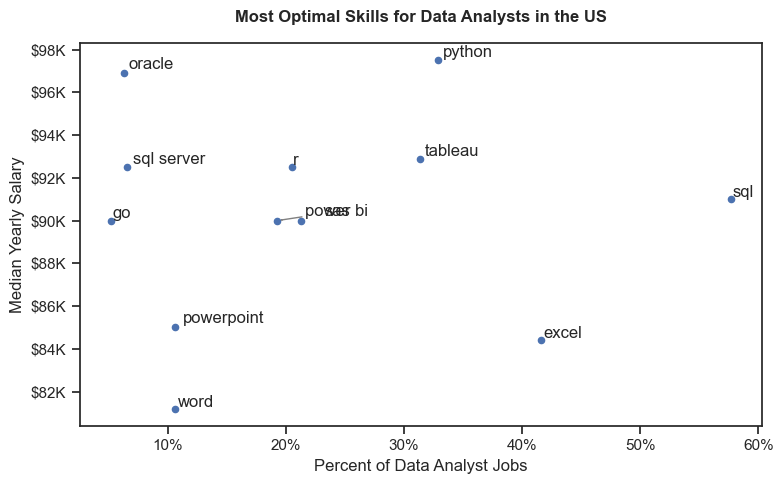

In [79]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary', figsize=(8, 5))

texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(
        df_DA_skills_high_demand['skill_percent'].iloc[i],
        df_DA_skills_high_demand['median_salary'].iloc[i],
        txt
    ))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.title('Most Optimal Skills for Data Analysts in the US', fontweight='bold', pad=15)
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter())

plt.tight_layout()
plt.show()

In [61]:
df_technology = df['job_type_skills']

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['spreadsheet',
  'ms access',
  'visio',
  'powerpoint',
  'sharepoint',
  'sap',
  'cognos',
  'word',
  'qlik',
  'excel',
  'msaccess',
  'power bi',
  'datarobot',
  'ssrs',
  'sheets',
  'esquisse',
  'microstrategy',
  'splunk',
  'outlook',
  'sas',
  'alteryx',
  'spss',
  'dax',
  'nuix',
  'powerbi',
  'looker',
  'ssis',
  'tableau'],
 'programming': ['pascal',
  'visualbasic',
  'elixir',
  'mongodb',
  'fortran',
  'haskell',
  'java',
  'perl',
  't-sql',
  'rust',
  'sql',
  'html',
  'crystal',
  'javascript',
  'assembly',
  'c#',
  'php',
  'swift',
  'powershell',
  'visual basic',
  'golang',
  'python',
  'lisp',
  'clojure',
  'nosql',
  'groovy',
  'c',
  'dart',
  'c++',
  'css',
  'shell',
  'lua',
  'r',
  'matlab',
  'vba',
  'cobol',
  'scala',
  'apl',
  'solidity',
  'erlang',
  'ocaml',
  'sas',
  'delphi',
  'mongo',
  'go',
  'sass',
  'bash',
  'typescript',
  'objective-c',
  'f#',
  'ruby',
  'kotlin',
  'julia',
  'vb.net',
  'no-

In [63]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,spreadsheet
0,analyst_tools,ms access
0,analyst_tools,visio
0,analyst_tools,powerpoint
0,analyst_tools,sharepoint
...,...,...
9,sync,webex
9,sync,slack
9,sync,google chat
9,sync,rocketchat


In [64]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

df_plot

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,893,92500.00,20.528736,programming,r
5,838,90000.00,19.264368,analyst_tools,power bi
6,462,85000.00,10.620690,analyst_tools,powerpoint
7,461,81194.75,10.597701,analyst_tools,word
8,286,92500.00,6.574713,databases,sql server
9,274,96923.75,6.298851,cloud,oracle


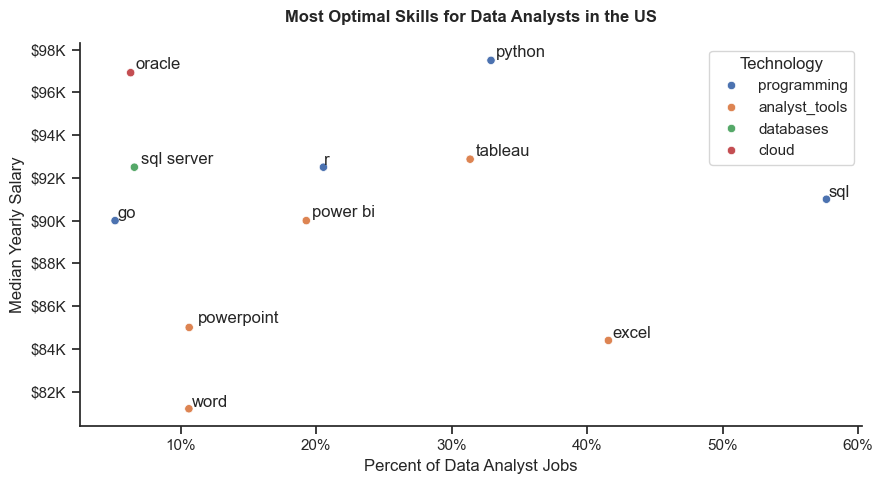

In [65]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df_plot, x='skill_percent', y='median_salary', hue='technology')
sns.despine()
sns.set_theme(style='ticks')

from adjustText import adjust_text
texts = []
for i, txt in enumerate(df_plot['skills']):
    texts.append(plt.text(
        df_plot['skill_percent'].iloc[i],
        df_plot['median_salary'].iloc[i],
        txt)
    )
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.title('Most Optimal Skills for Data Analysts in the US', fontweight='bold', pad=15)
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter())

plt.tight_layout()
plt.show()